# Projeto Integrador (P15): Entrega Final
## Previsão de Alta Demanda de Produtos da Bioeconomia Amazônica

**Disciplina:** Banco de Dados e Engenharia de Dados para IA
**Professor:** Adolfo Colares
**Curso:** Especialização em Inteligência Artificial, [UNIFAP – Universidade Federal do Amapá](https://www.unifap.br/)
**Autor:** Leonam Souza dos Santos Azevedo
**Repositório:** https://github.com/leonammeta8154/p15-projeto-integrador

Este notebook consolida o pipeline end-to-end de Engenharia de Dados e Machine Learning. Ele lê os resultados gerados pelo pipeline (banco PostgreSQL, relatórios e modelo salvo) e apresenta cada etapa com as decisões técnicas e os resultados obtidos. A análise detalhada de cada etapa está nos notebooks `01_eda`, `02_features` e `03_modelo`.

## Sumário executivo

- **Pergunta:** no início de cada mês, um município do Amapá, Pará ou Amazonas terá **alta demanda** de açaí, castanha-do-pará ou óleo de copaíba, em relação ao seu próprio histórico?
- **Dados:** 4 fontes, sendo 3 públicas e reais do IBGE (municípios, população do Censo 2022 e produção extrativa da PEVS) e 1 de vendas simuladas, ancorada nos dados do IBGE.
- **Pipeline:** coleta em Python → PostgreSQL em três camadas (`staging`, `dw` em estrela e `ml`) → ETL com 10 regras de qualidade auditadas → 16 features sem vazamento de dados → modelos de classificação com validação temporal.
- **Resultado:** o modelo final (**regressão logística**) atingiu, no teste de 2024, **Accuracy de 0,774, F1 de 0,772 e AUC de 0,861**, contra 0,737, 0,733 e 0,737 da melhor regra de referência ("repetir o mês anterior").
- **Principal ganho:** nos meses em que a demanda **muda de estado** (26% dos casos), a regra simples erra todos, e o modelo acerta **37%**, justamente na entrada e na saída da safra, quando o planejamento de estoque é mais crítico.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from src import config
from src.features import FEATURES_NUMERICAS, construir_features
from src.leitura import carregar_dw, montar_base_vendas
from src.modelagem import carregar_modelo

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.max_colwidth", None)
FIGURAS = config.REPORTS_DIR / "figuras"

def consultar(sql: str):
    """Executa uma consulta no PostgreSQL; devolve None se o banco não estiver disponível."""
    try:
        from sqlalchemy import text
        from src.db import criar_engine
        engine = criar_engine()
        with engine.connect() as conn:
            resultado = pd.read_sql(text(sql), conn)
        engine.dispose()
        return resultado
    except Exception as erro:
        print(f"Banco indisponível ({type(erro).__name__}); usando os arquivos gerados pelo pipeline.")
        return None

def figura(nome: str):
    display(Image(filename=str(FIGURAS / f"{nome}.png")))

## 1. Problema e objetivo

Na bioeconomia amazônica, a demanda por produtos como o açaí varia muito ao longo do ano, acompanhando a safra. Prever com antecedência os meses de **alta demanda** em cada município ajuda cooperativas e comerciantes a planejar compra, estoque e transporte, reduzindo falta de produto e desperdício de itens perecíveis.

**Variável alvo:** `alta_demanda = 1` quando a quantidade vendida no mês supera a média dos 12 meses anteriores do mesmo município e produto. O alvo compara cada município com o seu próprio histórico, então um município pequeno pode ter alta demanda tanto quanto uma capital.

**Tipo de problema:** classificação binária, avaliada com Accuracy, F1 (métrica principal), precisão, recall e AUC.

## 2. Arquitetura do pipeline

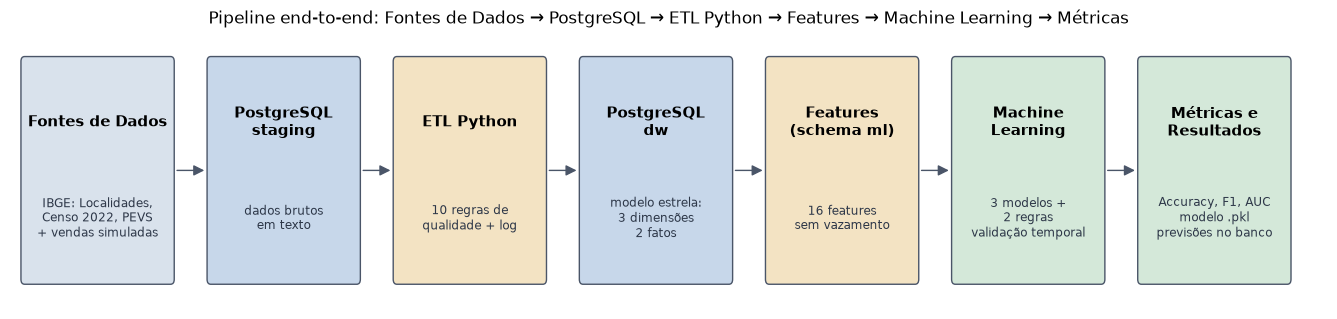

In [2]:
etapas = [
    ("Fontes de Dados", "IBGE: Localidades,\nCenso 2022, PEVS\n+ vendas simuladas", "#d9e2ec"),
    ("PostgreSQL\nstaging", "dados brutos\nem texto", "#c7d7ea"),
    ("ETL Python", "10 regras de\nqualidade + log", "#f3e3c3"),
    ("PostgreSQL\ndw", "modelo estrela:\n3 dimensões\n2 fatos", "#c7d7ea"),
    ("Features\n(schema ml)", "16 features\nsem vazamento", "#f3e3c3"),
    ("Machine\nLearning", "3 modelos +\n2 regras\nvalidação temporal", "#d4e8d9"),
    ("Métricas e\nResultados", "Accuracy, F1, AUC\nmodelo .pkl\nprevisões no banco", "#d4e8d9"),
]
fig, eixo = plt.subplots(figsize=(17, 3.6))
largura, altura, espaco = 2.0, 2.2, 0.55
for i, (titulo, detalhe, cor) in enumerate(etapas):
    x = i * (largura + espaco)
    eixo.add_patch(FancyBboxPatch((x, 0), largura, altura, boxstyle="round,pad=0.05", facecolor=cor, edgecolor="#4a5568"))
    eixo.text(x + largura / 2, altura * 0.72, titulo, ha="center", va="center", fontsize=10.5, fontweight="bold")
    eixo.text(x + largura / 2, altura * 0.28, detalhe, ha="center", va="center", fontsize=8.5, color="#2d3748")
    if i < len(etapas) - 1:
        eixo.add_patch(FancyArrowPatch((x + largura + 0.05, altura / 2), (x + largura + espaco - 0.05, altura / 2),
                                       arrowstyle="-|>", mutation_scale=16, color="#4a5568"))
eixo.set_xlim(-0.2, len(etapas) * (largura + espaco))
eixo.set_ylim(-0.3, altura + 0.3)
eixo.axis("off")
eixo.set_title("Pipeline end-to-end: Fontes de Dados → PostgreSQL → ETL Python → Features → Machine Learning → Métricas", fontsize=12)
fig.savefig(FIGURAS / "00_arquitetura.png", bbox_inches="tight", dpi=150)
plt.show()

| Etapa | Implementação | Comando |
|-------|---------------|---------|
| Coleta | `src/extract.py` (APIs do IBGE, com cache) e `src/gerar_vendas.py` | `python -m src.extract` e `python -m src.gerar_vendas` |
| Armazenamento | `sql/01_estrutura.sql` e `src/setup_db.py`; carga em `src/load_staging.py` | `python -m src.setup_db` e `python -m src.load_staging` |
| ETL | `src/transform.py` (regras) e `src/etl.py` (orquestração) | `python -m src.etl` |
| Features | `src/features.py` e `src/build_features.py` | `python -m src.build_features` |
| Modelo e métricas | `src/modelagem.py` e `src/train.py` | `python -m src.train` |
| **Tudo de uma vez** | `src/pipeline.py` | `python -m src.pipeline` |

## 3. Fontes de dados

| # | Fonte | Tipo | Conteúdo |
|---|-------|------|----------|
| 1 | API de Localidades do IBGE | Pública, real | 222 municípios de AP (16), PA (144) e AM (62) |
| 2 | SIDRA tabela 4709 (Censo 2022) | Pública, real | População residente por município |
| 3 | SIDRA tabela 289 (PEVS) | Pública, real | Produção extrativa por município, produto e ano (2021 a 2024) |
| 4 | Relatório de vendas | Simulada | Vendas mensais por município e produto, de jan/2022 a dez/2024 |

Não existe base pública de vendas mensais desses produtos por município. Por isso, as vendas são simuladas com semente fixa e ancoradas nos dados reais do IBGE: a demanda cresce com a população e com a produção local do ano anterior, segue a sazonalidade de cada produto e tem tendência e ruído. Para que o ETL tivesse o que tratar, como numa base real, o gerador insere 8 tipos de problemas de qualidade (duplicatas, grafias diferentes, datas em dois formatos, códigos e preços ausentes, erros de digitação e de sinal).

## 4. Armazenamento no PostgreSQL

In [3]:
tabelas = {
    "staging": ["stg_municipios", "stg_populacao", "stg_pevs", "stg_vendas"],
    "dw": ["dim_municipio", "dim_produto", "dim_tempo", "fato_producao_extrativa", "fato_vendas", "log_qualidade_etl"],
    "ml": ["features_demanda", "metricas_modelos", "previsoes_teste"],
}
sql = " UNION ALL ".join(
    f"SELECT {i} AS ordem, '{schema}' AS schema, '{tabela}' AS tabela, count(*) AS registros FROM {schema}.{tabela}"
    for i, (schema, tabela) in enumerate((s, t) for s, lista in tabelas.items() for t in lista)
) + " ORDER BY ordem"
contagem = consultar(sql)
contagem.drop(columns="ordem") if contagem is not None else pd.DataFrame(
    [(t, len(pd.read_csv(config.DATA_PROCESSED / f"{t}.csv"))) for t in
     ["dim_municipio", "dim_produto", "dim_tempo", "fato_producao_extrativa", "fato_vendas", "features_modelo", "previsoes_teste"]],
    columns=["arquivo", "registros"],
)

,schema,tabela,registros
0,staging,stg_municipios,222
1,staging,stg_populacao,666
2,staging,stg_pevs,111888
3,staging,stg_vendas,24167
4,dw,dim_municipio,222
5,dw,dim_produto,3
6,dw,dim_tempo,36
7,dw,fato_producao_extrativa,2664
8,dw,fato_vendas,23975
9,dw,log_qualidade_etl,50


O banco `bioeconomia` é organizado em **três camadas**, uma por schema:

- **`staging`:** recebe as quatro fontes exatamente como chegaram, tudo em texto, com o arquivo de origem e o horário da carga. Nada é rejeitado nessa camada, o que permite auditar qualquer valor tratado.
- **`dw`:** modelo dimensional em **estrela**, com as dimensões `dim_municipio`, `dim_produto` e `dim_tempo` e duas tabelas fato de granularidades diferentes: `fato_vendas` (mensal) e `fato_producao_extrativa` (anual). Tem tipos corretos, chaves primárias e estrangeiras, restrições `CHECK` e índices. A chave composta da `fato_vendas` (município, produto, mês) impede duplicatas no próprio banco.
- **`ml`:** base de modelagem (`features_demanda`), comparação dos modelos (`metricas_modelos`) e previsões do teste (`previsoes_teste`).

## 5. ETL em Python

In [4]:
qualidade = pd.read_csv(config.REPORTS_DIR / "qualidade_etl.csv")
qualidade[qualidade["registros"] > 0].reset_index(drop=True)

,tabela,regra,registros
0,dim_municipio,registros lidos da staging,222
1,fato_producao_extrativa,registros lidos da staging (todos os produtos),111888
2,fato_producao_extrativa,registros dos 3 produtos do projeto (demais ignorados),5328
3,fato_producao_extrativa,símbolo '-' do IBGE convertido em zero,2150
4,fato_producao_extrativa,"símbolos '...', '..' ou 'X' do IBGE convertidos em NULL (não disponível)",264
5,fato_producao_extrativa,registros gravados,2664
6,fato_vendas,registros lidos da staging,24167
7,fato_vendas,linhas duplicadas removidas,191
8,fato_vendas,nome do produto padronizado,3596
9,fato_vendas,mês convertido de MM/AAAA,2397


O ETL lê a staging, aplica as regras de `src/transform.py` e grava o modelo estrela **em uma única transação**: se algo falhar, o `dw` não fica pela metade. Cada regra registra quantos registros corrigiu ou descartou, em `dw.log_qualidade_etl` e no relatório acima.

- Das 24.167 linhas de vendas, foram removidas **191 duplicatas**, padronizados **3.596** nomes de produto, convertidos **2.397** meses do formato `MM/AAAA`, recuperados **119** códigos IBGE pelo nome do município e UF, corrigidos **47** sinais, recalculadas **70** quantidades com erro de digitação (a receita foi tomada como campo confiável) e **359** preços ausentes.
- Apenas **1 registro** foi descartado, por acumular dois erros na mesma linha sem informação suficiente para correção segura: **23.975** vendas gravadas de 23.976 originais.
- Na PEVS, o ETL mantém os 3 produtos do projeto, converte o símbolo `-` do IBGE em zero e `...` em `NULL` (dado não disponível).
- **Validação:** como as vendas são simuladas, existe um gabarito sem erros. Nos testes, o ETL recuperou exatamente os valores originais de quantidade, preço e receita em todos os registros gravados.

## 6. Análise exploratória

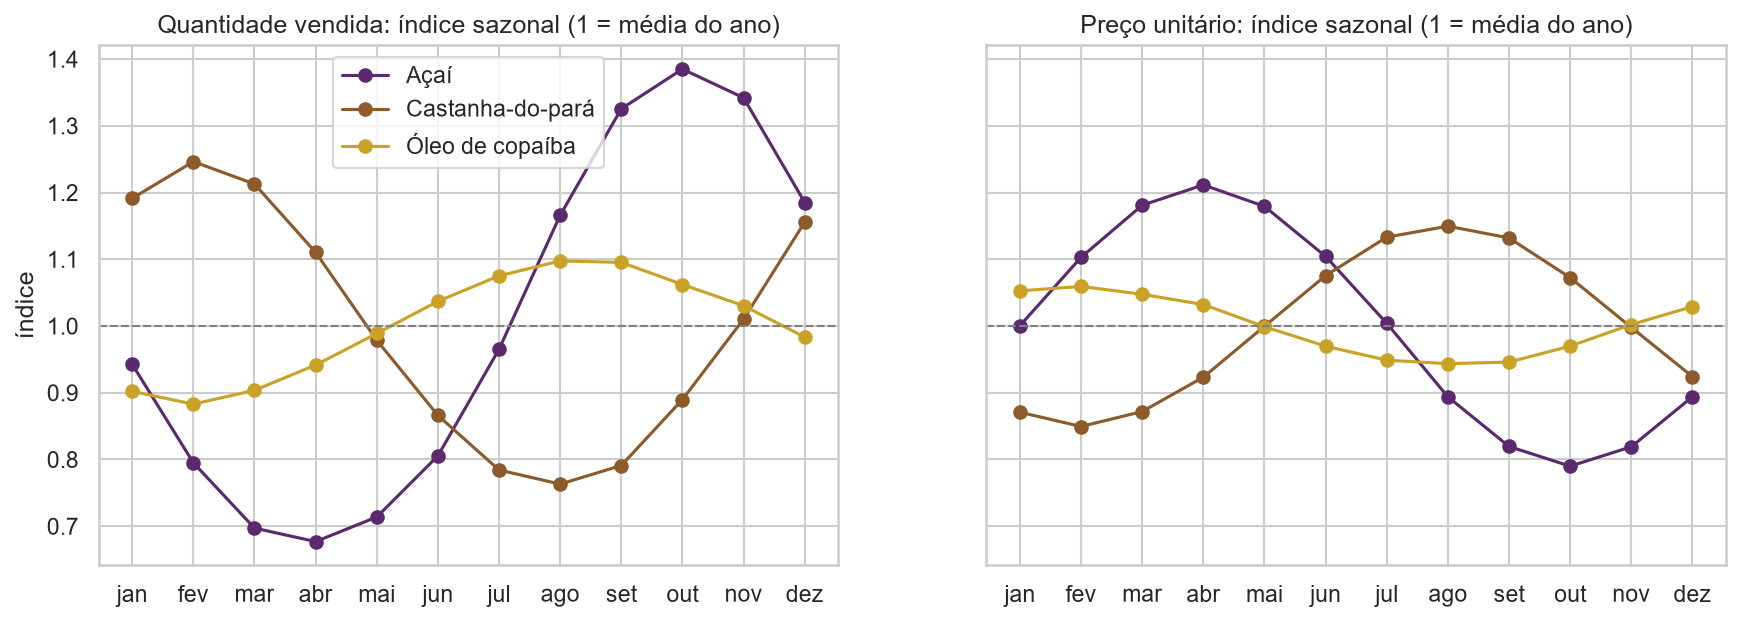

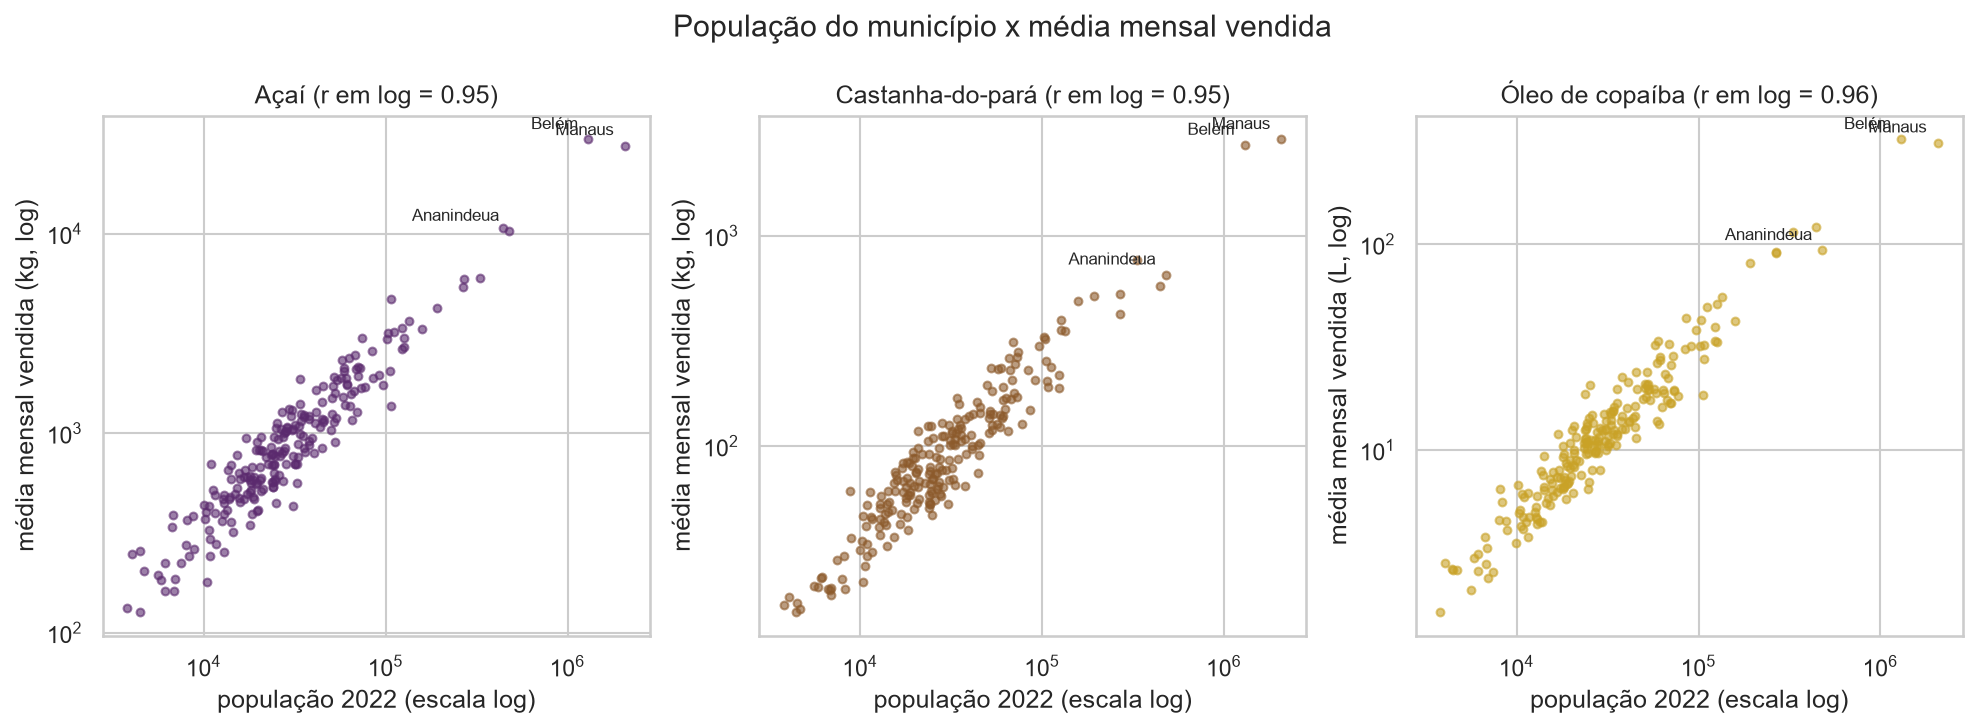

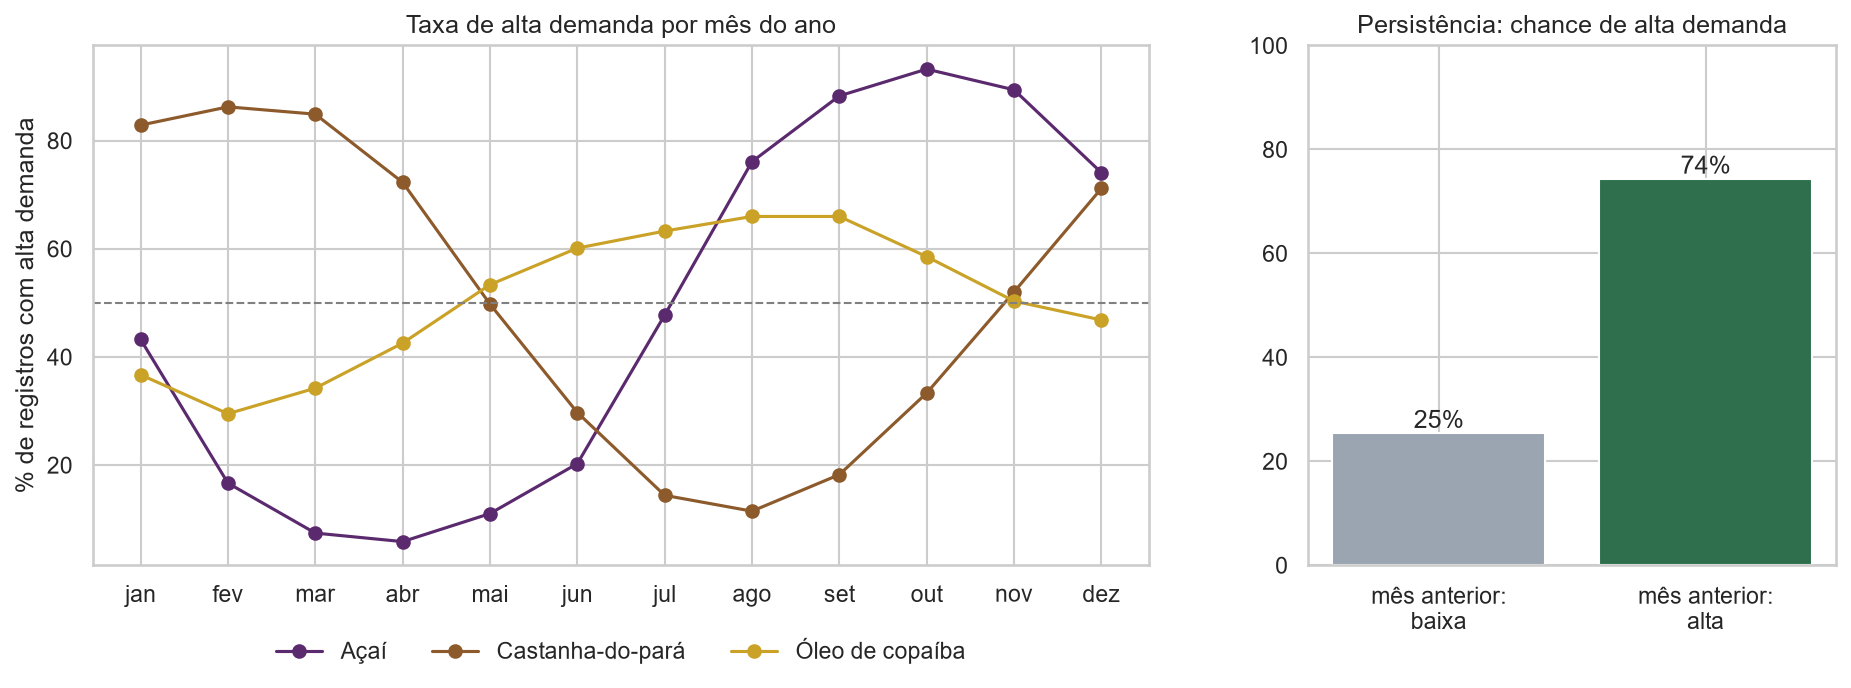

In [5]:
figura("03_sazonalidade")
figura("05_populacao_vendas")
figura("08_alvo_sazonalidade_persistencia")

Principais achados (detalhes em `01_eda.ipynb`):

- **Sazonalidade forte e própria de cada produto:** o açaí tem pico em outubro e vale em abril; a castanha-do-pará, pico em fevereiro e vale em agosto; o óleo de copaíba varia pouco. O preço se move no sentido oposto à quantidade.
- **Volume dominado pela população:** a relação entre população e vendas é quase linear em escala log-log. Por isso o alvo é relativo ao histórico de cada município, e as variáveis de volume entram como razões.
- **Persistência:** depois de um mês de alta demanda, a chance de outro mês de alta é de **74%**, contra **25%** depois de um mês de baixa.
- **Produção local:** municípios que produziram no ano anterior vendem mais por habitante, mas a produção quase não se correlaciona com o alvo mensal; entra no modelo como contexto.

## 7. Engenharia de features

In [6]:
dicionario = pd.read_csv(config.REPORTS_DIR / "dicionario_features.csv")
dicionario

,feature,grupo,descricao,informacao_usada
0,log_razao_lag1,Memória recente,Log da razão entre a quantidade do mês anterior e a média dos 12 meses anteriores,t-1
1,log_razao_lag2,Memória recente,Log da razão entre a quantidade de dois meses antes e a média dos 12 meses anteriores,t-2
2,log_razao_media3,Memória recente,Log da razão entre a média dos últimos 3 meses e a média dos 12 meses anteriores,t-3 a t-1
3,log_variacao_lag1,Memória recente,Log da variação da quantidade entre os dois últimos meses,t-2 e t-1
4,alta_mes_anterior,Memória recente,"Alvo do mês anterior (1 = alta demanda); vazio em jan/2023, pois 2022 não tem alvo",t-1
5,log_razao_lag12,Sazonalidade,Log da razão entre a quantidade do mesmo mês do ano anterior e a média dos 12 meses anteriores,t-12
6,indice_sazonal_hist,Sazonalidade,"Índice sazonal do produto no mês do ano, calculado só com os anos anteriores",anos anteriores
7,mes_seno,Sazonalidade,Seno do mês do ano (codificação cíclica),calendário
8,mes_cosseno,Sazonalidade,Cosseno do mês do ano (codificação cíclica),calendário
9,log_preco_rel_lag1,Preço,Log da razão entre o preço do mês anterior e a média de preço dos 12 meses anteriores,t-1


In [7]:
# Teste de vazamento: altera as vendas de um mês e confere que nenhuma feature
# daquele mês ou dos anteriores muda (as dos meses seguintes devem mudar).
dw, origem = carregar_dw()
base = montar_base_vendas(dw)
chave = ["cod_ibge", "id_produto", "id_tempo"]
original = construir_features(base).set_index(chave)[FEATURES_NUMERICAS].astype(float)

mes = 202405
alterada = base.copy()
alterada.loc[alterada["id_tempo"] == mes, ["quantidade", "receita"]] *= 10
nova = construir_features(alterada).set_index(chave)[FEATURES_NUMERICAS].astype(float).reindex(original.index)
mudou = ~np.isclose(original.to_numpy(), nova.to_numpy(), equal_nan=True)
ate_mes = original.index.get_level_values("id_tempo") <= mes

print(f"Base de modelagem: {len(original):,} registros e {len(dicionario)} features (dados lidos de {origem})")
print(f"Valores alterados até o mês {mes} (deve ser 0): {mudou[ate_mes].sum()}")
print(f"Valores alterados depois do mês {mes} (deve ser > 0): {mudou[~ate_mes].sum():,}")
assert mudou[ate_mes].sum() == 0, "Vazamento detectado!"

Base de modelagem: 15,982 registros e 16 features (dados lidos de PostgreSQL (schema dw))
Valores alterados até o mês 202405 (deve ser 0): 0
Valores alterados depois do mês 202405 (deve ser > 0): 22,266


- As **16 features** usam apenas informação disponível **até o mês anterior** ao previsto, divididas em memória recente, sazonalidade, preço e contexto. As defasagens seguem o calendário, não a posição da linha na tabela.
- O **teste de vazamento** acima comprova essa regra: alterar as vendas de um mês não muda nenhuma feature daquele mês nem dos anteriores.
- A base tem **15.982 registros**: 7.992 no treino (2023) e 7.990 no teste (2024), com taxa de alta demanda próxima de 50% nos dois conjuntos.
- Detalhes, distribuições e relevância das features estão em `02_features.ipynb`.

## 8. Modelo e métricas

In [8]:
metricas = consultar("SELECT * FROM ml.metricas_modelos")
if metricas is None:
    metricas = pd.read_csv(config.REPORTS_DIR / "metricas_modelos.csv")
metricas.set_index("modelo")[["tipo", "melhores_parametros", "f1_validacao", "accuracy", "f1", "precisao", "recall", "auc"]]

,tipo,melhores_parametros,f1_validacao,accuracy,f1,precisao,recall,auc
modelo,,,,,,,,
Regra: repetir o mês anterior,referência,-,0.754,0.737,0.733,0.731,0.734,0.737
Regra: época de safra (índice sazonal > 1),referência,-,0.766,0.717,0.707,0.721,0.693,0.795
Regressão logística,aprendizado de máquina,C=10.0,0.796,0.774,0.772,0.764,0.779,0.861
Random Forest,aprendizado de máquina,"max_depth=None, min_samples_leaf=5",0.775,0.775,0.773,0.766,0.780,0.858
Gradient Boosting,aprendizado de máquina,"learning_rate=0.03, max_leaf_nodes=15",0.796,0.771,0.769,0.762,0.776,0.858


In [9]:
pacote = carregar_modelo()
pd.Series(
    {
        "modelo final": pacote["nome"],
        "parâmetros": pacote["parametros"],
        "período de treino": pacote["periodo_treino"],
        "Accuracy (teste 2024)": round(pacote["metricas_teste_2024"]["accuracy"], 3),
        "F1 (teste 2024)": round(pacote["metricas_teste_2024"]["f1"], 3),
        "AUC (teste 2024)": round(pacote["metricas_teste_2024"]["auc"], 3),
        "treinado em": pacote["treinado_em"],
        "scikit-learn": pacote["versao_scikit_learn"],
    },
    name="models/modelo_alta_demanda.pkl",
).to_frame()

,models/modelo_alta_demanda.pkl
modelo final,Regressão logística
parâmetros,C=10.0
período de treino,jan/2023 a dez/2023
Accuracy (teste 2024),0.774
F1 (teste 2024),0.772
AUC (teste 2024),0.861
treinado em,2026-10-03T14:56:05
scikit-learn,1.9.1


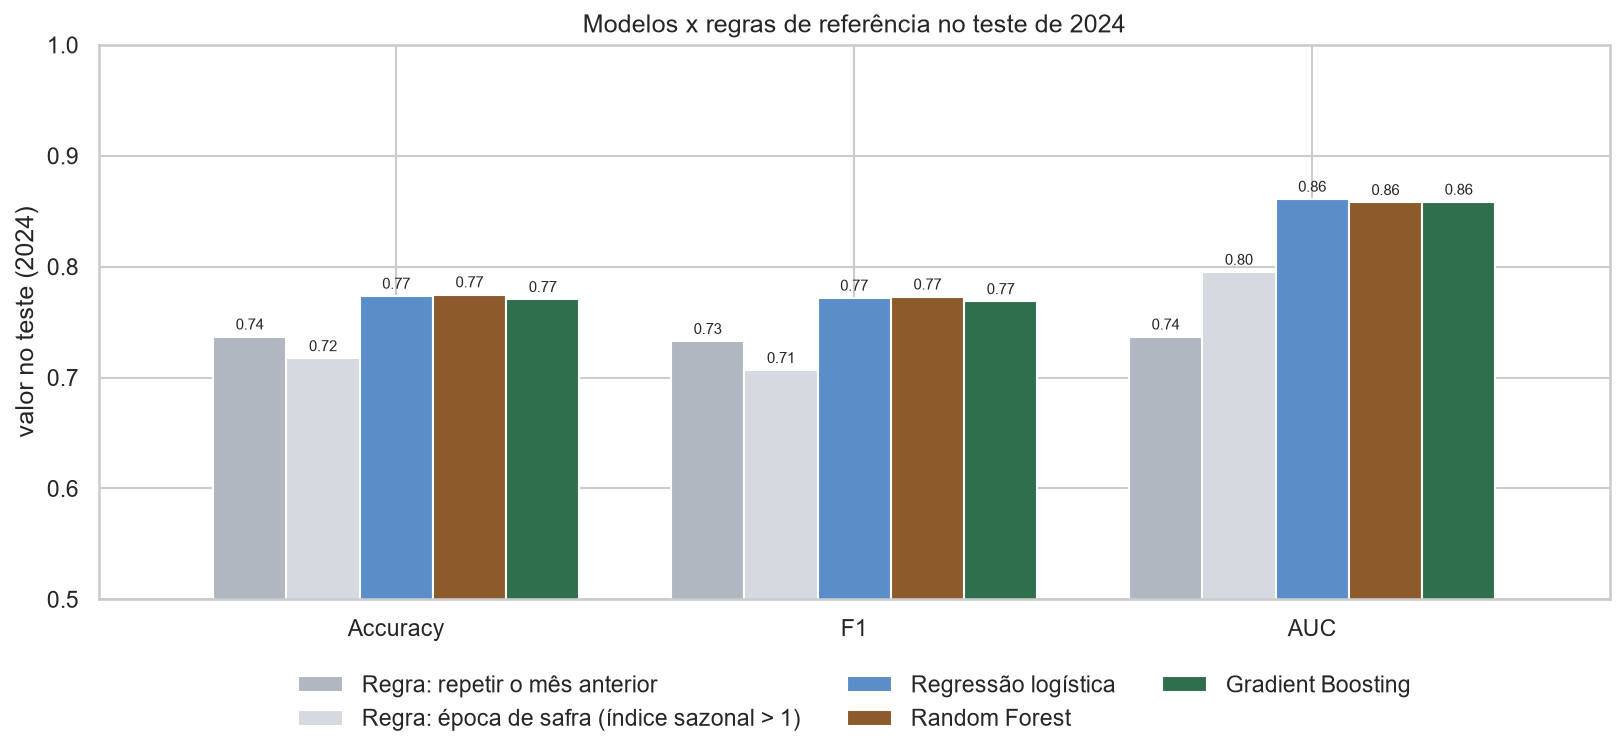

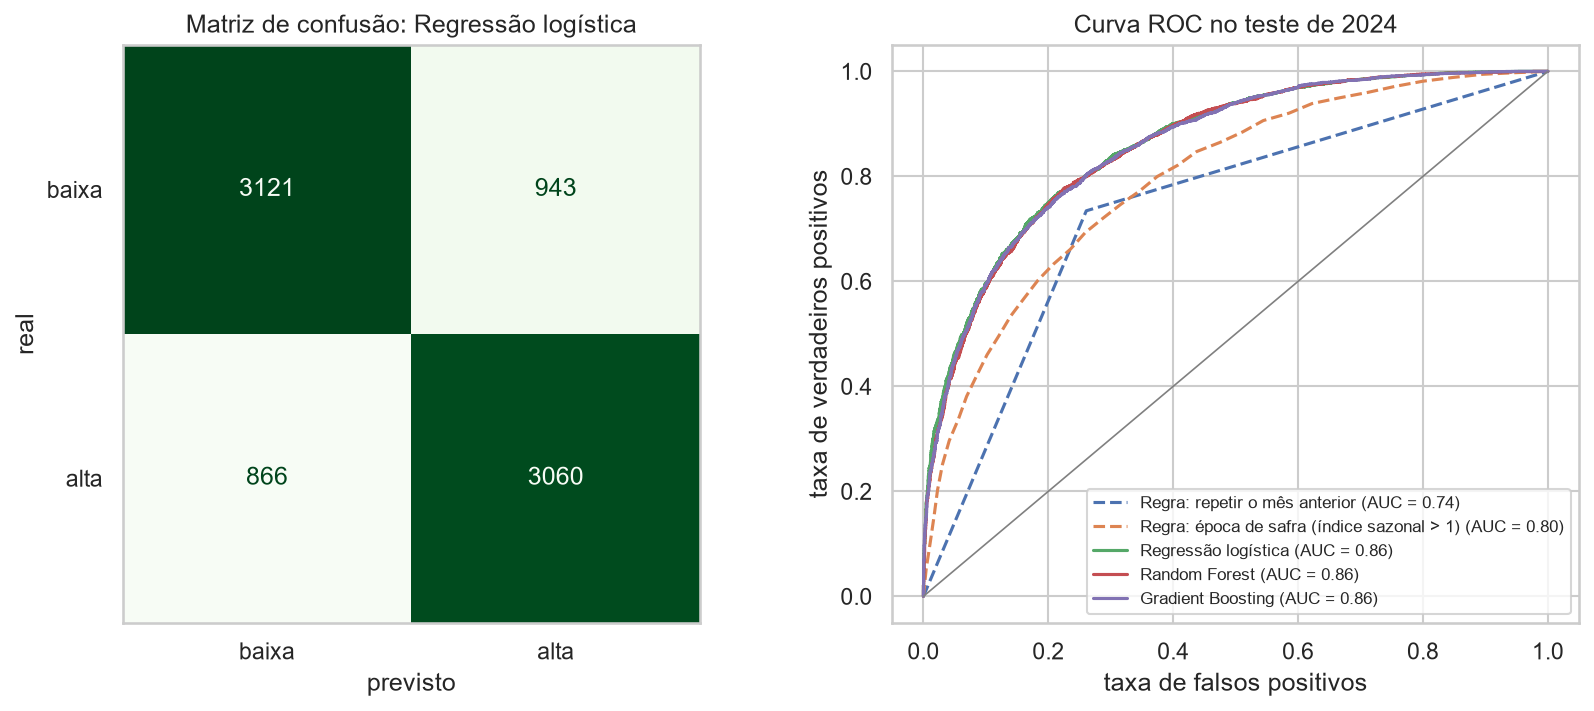

In [10]:
figura("14_comparacao_modelos")
figura("15_matriz_confusao_roc")

**Metodologia de avaliação**

- **Treino em 2023 e teste em 2024**, sem embaralhar. O teste foi usado uma única vez, na avaliação final.
- **Seleção por validação temporal dentro de 2023**, com janela crescente (treina até junho e valida em julho e agosto; até agosto, valida em setembro e outubro; até outubro, valida em novembro e dezembro). Hiperparâmetros e modelo final foram escolhidos pela média do F1 nessa validação.
- **Pré-processamento dentro do pipeline** (imputação, padronização e codificação), ajustado só com os dados de treino.
- **Duas regras sem aprendizado como referência**, que o modelo precisa superar para se justificar.

## 9. Resultados e análise

,registros,f1_modelo,f1_regra_mes_anterior,accuracy_modelo,ganho_f1
nome,,,,,
Açaí,2664,0.834,0.767,0.843,0.067
Castanha-do-pará,2664,0.779,0.745,0.772,0.034
Óleo de copaíba,2662,0.707,0.686,0.705,0.021


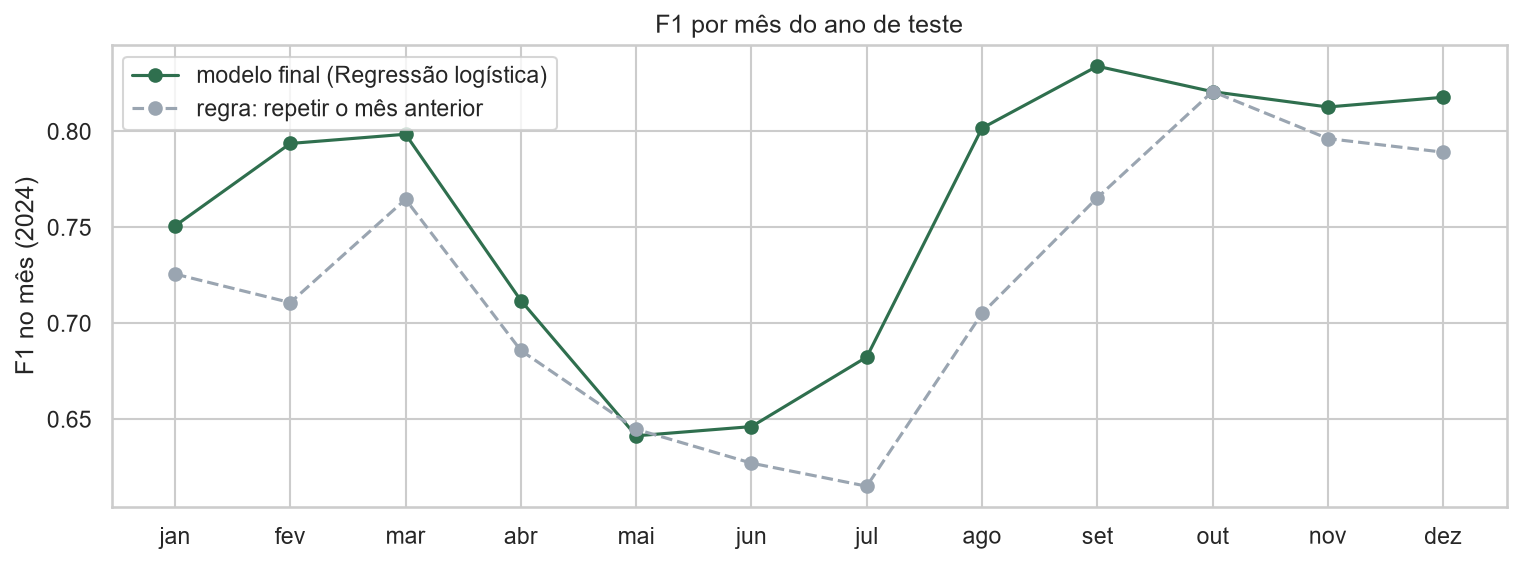

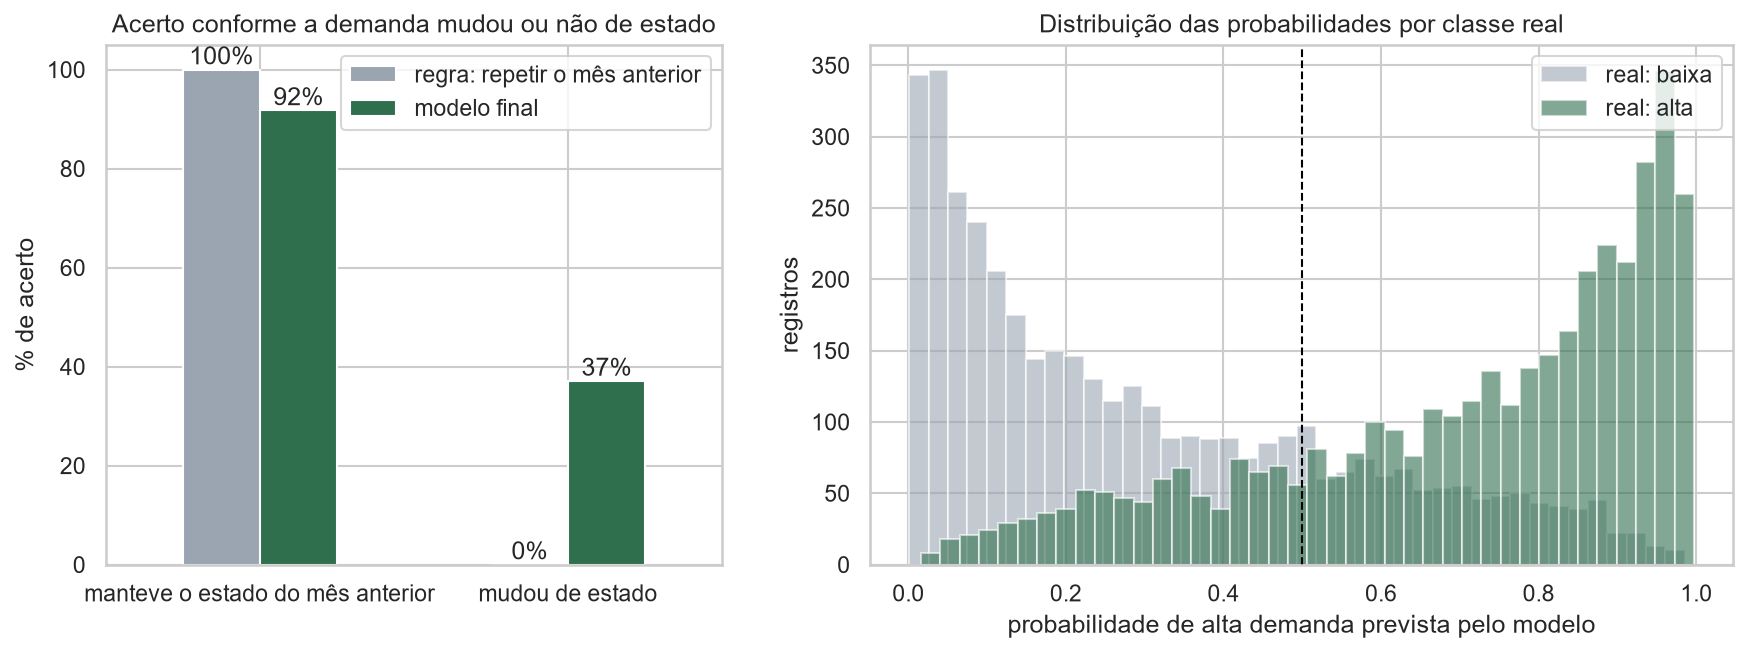

In [11]:
por_produto = pd.read_csv(config.REPORTS_DIR / "metricas_por_produto.csv").set_index("nome")
por_produto["ganho_f1"] = por_produto["f1_modelo"] - por_produto["f1_regra_mes_anterior"]
display(por_produto)
figura("16_f1_por_mes")
figura("18_ganho_e_probabilidades")

**1. O modelo supera as regras de referência.** A regressão logística, escolhida pela validação temporal, atingiu no teste de 2024 **F1 de 0,772, Accuracy de 0,774 e AUC de 0,861**. Sobre a regra "repetir o mês anterior", o ganho é de **+3,9 pontos de F1, +3,7 de Accuracy e +12,4 de AUC**. Os erros estão equilibrados entre falsos positivos (943) e falsos negativos (866), com precisão e recall próximos de 0,77 nas duas classes.

**2. As features importam mais que o algoritmo.** Regressão logística, Random Forest e Gradient Boosting ficaram com F1 entre 0,769 e 0,773 no teste. A validação escolheu o modelo mais simples e interpretável. A importância por permutação mostra que ele se apoia principalmente na **razão do mês anterior** (memória recente) e no **índice sazonal histórico**, como a análise exploratória indicava.

**3. O ganho está nas viradas de demanda.** Em 26% dos meses de 2024 a demanda mudou de estado em relação ao mês anterior. Nesses casos, a regra simples erra todos, e o modelo acerta **37%**. Quando a demanda mantém o estado, o modelo acerta **92%**. As maiores vantagens por mês aparecem em fevereiro, julho e agosto, nas viradas da safra de castanha e de açaí.

**4. O desempenho acompanha a força da sazonalidade.** O F1 é maior no **açaí (0,833)**, cuja safra é a mais marcada, intermediário na **castanha-do-pará (0,779)** e menor no **óleo de copaíba (0,707)**, cuja demanda varia pouco ao longo do ano e depende mais de oscilações aleatórias.

**5. As probabilidades são úteis para decidir.** Em 85% dos registros o modelo fica confiante (probabilidade fora da faixa de 0,4 a 0,6) e acerta **81,5%**; na faixa de incerteza, o acerto cai para 54%. Na prática, os casos de alta probabilidade permitem agir com segurança, e os intermediários pedem cautela.

**6. Não houve sobreajuste.** O F1 caiu um pouco da validação (2023) para o teste (2024), mas as regras de referência, que não aprendem nada, caíram na mesma proporção ou mais: 2024 foi um ano um pouco mais difícil de prever.

## 10. Conclusões, limitações e próximos passos

**Conclusões**

- O pipeline integra as sete etapas exigidas, de forma **reproduzível**: um único comando (`python -m src.pipeline`) refaz tudo, da coleta ao modelo, e os resultados são idênticos a cada execução (cache das fontes e sementes fixas).
- O PostgreSQL é o centro do pipeline: guarda os dados brutos, o modelo estrela tratado, a base de modelagem, as métricas e as previsões.
- A qualidade dos dados é **auditável** (log de cada regra do ETL) e a avaliação do modelo é **honesta** (features sem vazamento comprovado, divisão temporal e teste usado uma única vez).
- O modelo responde à pergunta de negócio com ganho real sobre as regras simples, principalmente nos meses de virada da safra.

**Limitações**

- As vendas são simuladas: as relações aprendidas refletem as regras da simulação, ancoradas em dados reais do IBGE. Com dados reais de cooperativas, o mesmo pipeline pode ser reaplicado.
- O teste cobre um único ano. Mais anos de histórico permitiriam avaliar a estabilidade em safras atípicas.
- O limiar de decisão ficou em 0,5. Se a falta de produto custar mais do que a sobra, o limiar pode ser reduzido para priorizar o recall.

**Próximos passos**

- Ajustar o limiar ao custo de cada tipo de erro.
- Incluir variáveis climáticas (como chuvas do INMET), que influenciam a safra.
- Disponibilizar o modelo por uma API, como no bônus do P14, e agendar o pipeline para rodar a cada mês.

## 11. Como reproduzir

Pré-requisitos: Python 3.10+, Git e PostgreSQL (testado nas versões 16 e 18). No Windows (PowerShell):

```powershell
git clone https://github.com/leonammeta8154/p15-projeto-integrador.git
cd p15-projeto-integrador
python -m venv .venv
.\.venv\Scripts\Activate.ps1
pip install -r requirements.txt
copy .env.example .env      # preencha a senha do PostgreSQL no .env
python -m src.pipeline      # executa as 7 etapas, da coleta ao modelo
```

Depois, execute os notebooks em `notebooks/` na ordem (`01_eda`, `02_features`, `03_modelo` e este). Sem PostgreSQL, os notebooks usam as cópias em CSV de `data/processed`, já incluídas no repositório.